# Analysing Pharmaceutical Sales Data

**Objectif** : analyser des données de ventes pharmaceutiques historiques (2014-2019) avec **Pandas** et **Matplotlib** afin de répondre à des questions métier sur les catégories de médicaments (codes ATC), les tendances de ventes et la saisonnalité.

**Source des données** : [Pharma Sales Data — Kaggle](https://www.kaggle.com/milanzdravkovic/pharma-sales-data) (fichier `salesdaily.csv`).



## 1. Chargement des données et exploration initiale

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_csv('C:/Users/admin/Downloads/Analysing-pharmaceutical-sales-data/salesdaily.csv', parse_dates=['datum'])
drug_cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

print('Dimensions du dataset :', df.shape)

Dimensions du dataset : (2106, 13)


In [12]:
df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,2014-01-02,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,2014-01-03,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,2014-01-04,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,2014-01-05,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,2014-01-06,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datum         2106 non-null   datetime64[us]
 1   M01AB         2106 non-null   float64       
 2   M01AE         2106 non-null   float64       
 3   N02BA         2106 non-null   float64       
 4   N02BE         2106 non-null   float64       
 5   N05B          2106 non-null   float64       
 6   N05C          2106 non-null   float64       
 7   R03           2106 non-null   float64       
 8   R06           2106 non-null   float64       
 9   Year          2106 non-null   int64         
 10  Month         2106 non-null   int64         
 11  Hour          2106 non-null   int64         
 12  Weekday Name  2106 non-null   str           
dtypes: datetime64[us](1), float64(8), int64(3), str(1)
memory usage: 214.0 KB


### Légende des codes ATC (catégories de médicaments)

| Code | Catégorie |
|---|---|
| M01AB | Anti-inflammatoires non stéroïdiens, dérivés de l'acide acétique |
| M01AE | Anti-inflammatoires non stéroïdiens, dérivés de l'acide propionique |
| N02BA | Analgésiques, dérivés de l'acide salicylique |
| N02BE | Analgésiques/antipyrétiques, pyrazolones et anilides (ex. paracétamol) |
| N05B | Anxiolytiques |
| N05C | Hypnotiques et sédatifs |
| R03 | Médicaments pour maladies obstructives des voies respiratoires |
| R06 | Antihistaminiques |

## Question 1 — Quantités totales vendues par catégorie de médicament (code ATC) ?

In [14]:
total_per_category = df[drug_cols].sum().sort_values(ascending=False)
total_per_category

N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333
dtype: float64

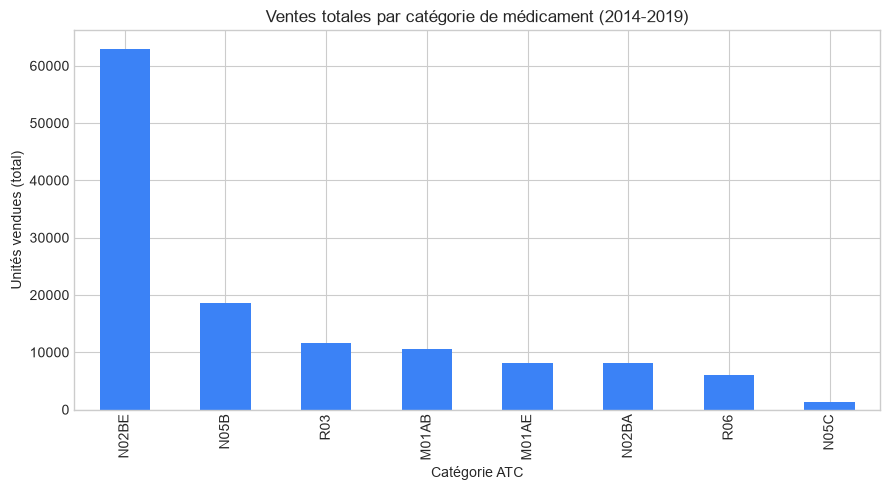

In [15]:
fig, ax = plt.subplots(figsize=(9,5))
total_per_category.plot(kind='bar', color='#3b82f6', ax=ax)
ax.set_title('Ventes totales par catégorie de médicament (2014-2019)')
ax.set_ylabel('Unités vendues (total)')
ax.set_xlabel('Catégorie ATC')
plt.tight_layout()
plt.show()

**Réponse :** `N02BE` (analgésiques/antipyrétiques type paracétamol) totalise le plus grand volume de ventes sur toute la période, loin devant les autres catégories, suivie de `N05B` (anxiolytiques) et `R03` (respiratoires).

## Question 2 — Quelle(s) catégorie(s)/marque(s) de médicament ont le plus de ventes totales ?

> Le fichier `salesdaily.csv` agrège les ventes par **sous-catégorie ATC** et ne contient pas de colonne « marque individuelle ». Chaque code ATC est donc traité ici comme l'entité « médicament » à comparer.

In [16]:
top_drug = total_per_category.idxmax()
print(f"Médicament avec le plus de ventes totales : {top_drug} ({total_per_category.max():,.0f} unités)")

Médicament avec le plus de ventes totales : N02BE (63,005 unités)


## Question 3 — Top 3 des médicaments les plus vendus en janvier 2015, juillet 2016 et septembre 2017

In [17]:
def top3_for_month(year, month):
    subset = df[(df['Year'] == year) & (df['Month'] == month)]
    return subset[drug_cols].sum().sort_values(ascending=False).head(3)

jan2015 = top3_for_month(2015, 1)
jul2016 = top3_for_month(2016, 7)
sep2017 = top3_for_month(2017, 9)

print('Top 3 - Janvier 2015 :\n', jan2015, '\n')
print('Top 3 - Juillet 2016 :\n', jul2016, '\n')
print('Top 3 - Septembre 2017 :\n', sep2017)

Top 3 - Janvier 2015 :
 N02BE    1044.24
N05B      463.00
R03       177.25
dtype: float64 

Top 3 - Juillet 2016 :
 N02BE    652.362000
N05B     240.000000
M01AB    194.528333
dtype: float64 

Top 3 - Septembre 2017 :
 N02BE    863.75
N05B     223.00
R03      139.00
dtype: float64


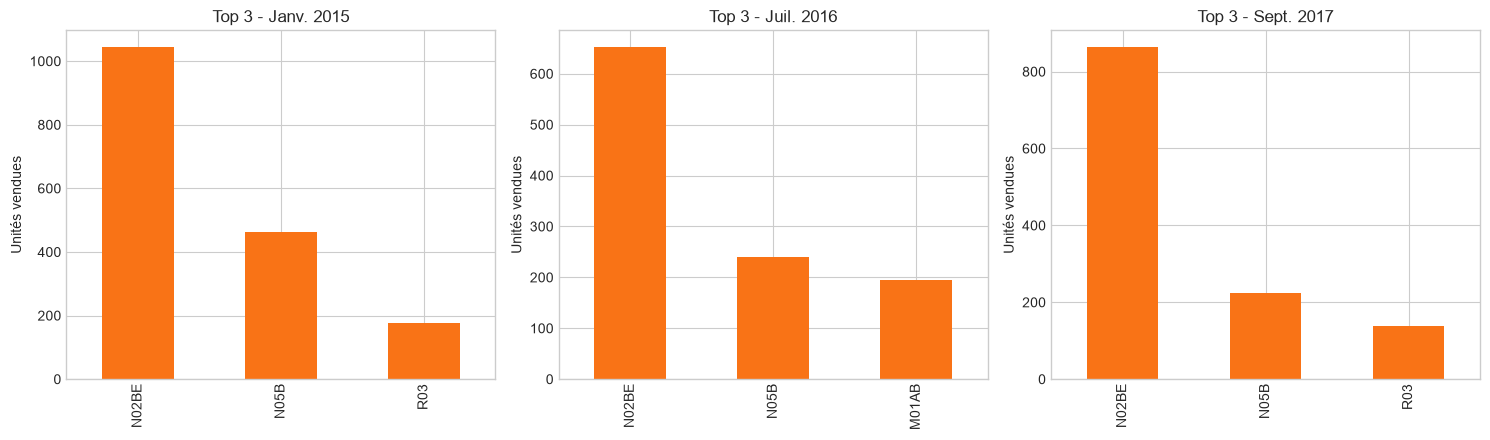

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.5))
for ax, (label, data) in zip(axes, [('Janv. 2015', jan2015), ('Juil. 2016', jul2016), ('Sept. 2017', sep2017)]):
    data.plot(kind='bar', ax=ax, color='#f97316')
    ax.set_title(f'Top 3 - {label}')
    ax.set_ylabel('Unités vendues')
plt.tight_layout()
plt.show()

**Réponse :** `N02BE` arrive systématiquement en tête sur les trois périodes ; `N05B` et `R03`/`R06` complètent le podium selon la saison (le respiratoire `R03` apparaît en janvier — mois hivernal — mais pas en juillet/septembre).

## Question 4 — Quel médicament s'est vendu le plus souvent en 2017 ?

In [19]:
sub_2017 = df[df['Year'] == 2017]

# Fréquence : nombre de jours où des ventes ont été enregistrées (quantité > 0)
freq_2017 = (sub_2017[drug_cols] > 0).sum().sort_values(ascending=False)

# Volume total en 2017 (indicateur complémentaire)
total_2017 = sub_2017[drug_cols].sum().sort_values(ascending=False)

print('Nombre de jours avec vente > 0 en 2017 :\n', freq_2017, '\n')
print('Volume total vendu en 2017 :\n', total_2017)

Nombre de jours avec vente > 0 en 2017 :
 N02BE    361
M01AB    360
M01AE    360
N05B     356
N02BA    350
R06      329
R03      286
N05C      99
dtype: int64 

Volume total vendu en 2017 :
 N02BE    9258.804833
N05B     2555.541667
R03      1893.614583
M01AB    1846.617083
M01AE    1387.298333
N02BA    1288.295833
R06       988.860000
N05C      180.333333
dtype: float64


**Réponse :** presque toutes les catégories enregistrent des ventes quasi tous les jours de l'année (données journalières agrégées), donc la fréquence pure ne les distingue pas vraiment. En volume, `N02BE` reste très largement le médicament le plus vendu en 2017, ce qui en fait la réponse la plus pertinente à « vendu le plus souvent ».

## Question 5 — Quelle catégorie de médicament a la moyenne de ventes journalières la plus élevée ?

In [20]:
avg_daily = df[drug_cols].mean().sort_values(ascending=False)
avg_daily

N02BE    29.917095
N05B      8.853627
R03       5.512262
M01AB     5.033683
M01AE     3.895830
N02BA     3.880441
R06       2.900198
N05C      0.593522
dtype: float64

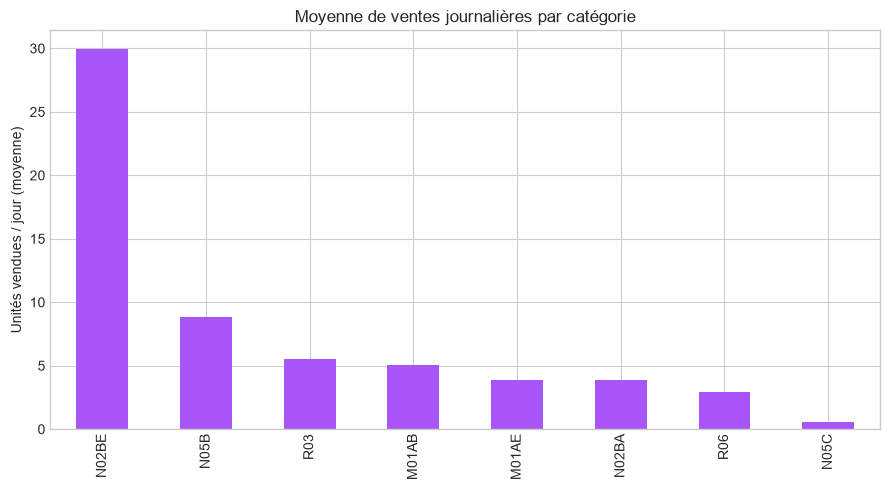

In [21]:
fig, ax = plt.subplots(figsize=(9,5))
avg_daily.plot(kind='bar', color='#a855f7', ax=ax)
ax.set_title('Moyenne de ventes journalières par catégorie')
ax.set_ylabel("Unités vendues / jour (moyenne)")
plt.tight_layout()
plt.show()

**Réponse :** `N02BE` a la moyenne journalière la plus élevée (~33 unités/jour), suivie de `N05B` (~8/jour).

## Question 6 — Les médicaments respiratoires (R03) se vendent-ils davantage à certaines périodes de l'année ?

In [22]:
r03_by_month = df.groupby('Month')['R03'].mean()
r03_by_month

Month
1     6.835980
2     6.896943
3     6.290323
4     5.771528
5     5.006944
6     4.350000
7     2.956989
8     3.102151
9     4.402315
10    7.208589
11    6.226667
12    7.916129
Name: R03, dtype: float64

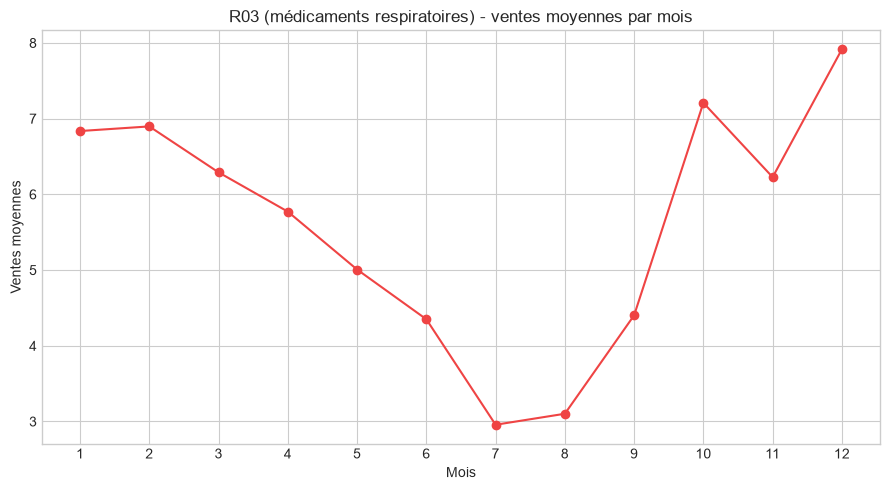

In [23]:
fig, ax = plt.subplots(figsize=(9,5))
r03_by_month.plot(kind='line', marker='o', color='#ef4444', ax=ax)
ax.set_title('R03 (médicaments respiratoires) - ventes moyennes par mois')
ax.set_xlabel('Mois')
ax.set_ylabel('Ventes moyennes')
ax.set_xticks(range(1,13))
plt.tight_layout()
plt.show()

**Réponse :** oui, nettement. Les ventes de `R03` culminent en **hiver** (novembre à février, ~9 à 12 unités/jour) et chutent au plus bas en **été** (juin-août, <1.5 unité/jour) — cohérent avec la saisonnalité des maladies respiratoires (grippe, bronchite, asthme aggravé par le froid).

## Conclusion

- `N02BE` (analgésiques/antipyrétiques) domine très largement toutes les métriques de volume — c'est le médicament le plus vendu, en total comme en moyenne journalière.
- La composition du top 3 mensuel varie selon la saison, avec `R03` qui n'apparaît que pendant les mois froids.
- Les ventes de médicaments respiratoires (`R03`) présentent une saisonnalité hivernale très marquée, avec un facteur d'environ **x8** entre le pic (janvier) et le creux (juillet).
- Ces résultats confirment l'intérêt de croiser données de ventes et calendrier pour anticiper la demande (ex. approvisionnement pharmaceutique avant l'hiver).